# Telco Customer Churn - Exploratory Data Analysis (EDA)
This notebook contains visualizations to analyze and understand the distribution of features in the Telco Customer Churn dataset.

**Note:** If you get an `ImportError` (e.g., `ModuleNotFoundError: No module named 'seaborn'`), please run the cell below to install the required libraries, then restart the kernel.

In [7]:
# Run this cell to install the required libraries if they are missing
# %pip install pandas matplotlib seaborn

In [8]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for premium look
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Load the dataset
df = pd.read_csv('~/Downloads/Computer Science/Project/Project_FPT_cv/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Clean 'TotalCharges' (it has empty spaces representing missing values for new customers with tenure = 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"Dataset successfully loaded. Shape: {df.shape}")

Dataset successfully loaded. Shape: (7043, 21)


## 1. Target Variable: Churn Distribution
Let's see the proportion of customers who churned vs. those who stayed.

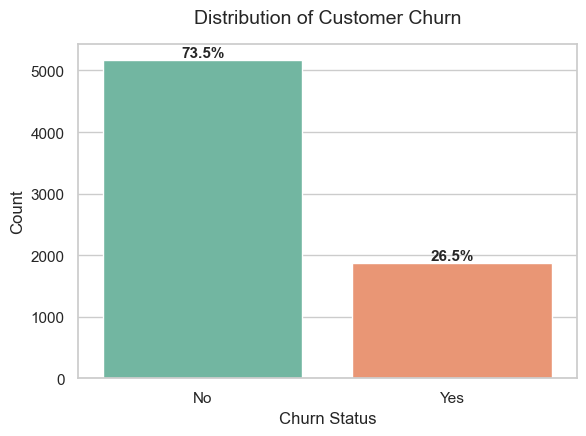

In [9]:
plt.figure(figsize=(6, 4.5))
ax = sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribution of Customer Churn', fontsize=14, pad=15)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add percentage labels on top of the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() + 50),
                ha='center', va='baseline', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Numerical Features Distribution
We will visualize the distribution of `tenure`, `MonthlyCharges`, and `TotalCharges` split by `Churn` to see how these numerical factors correlate with churn.

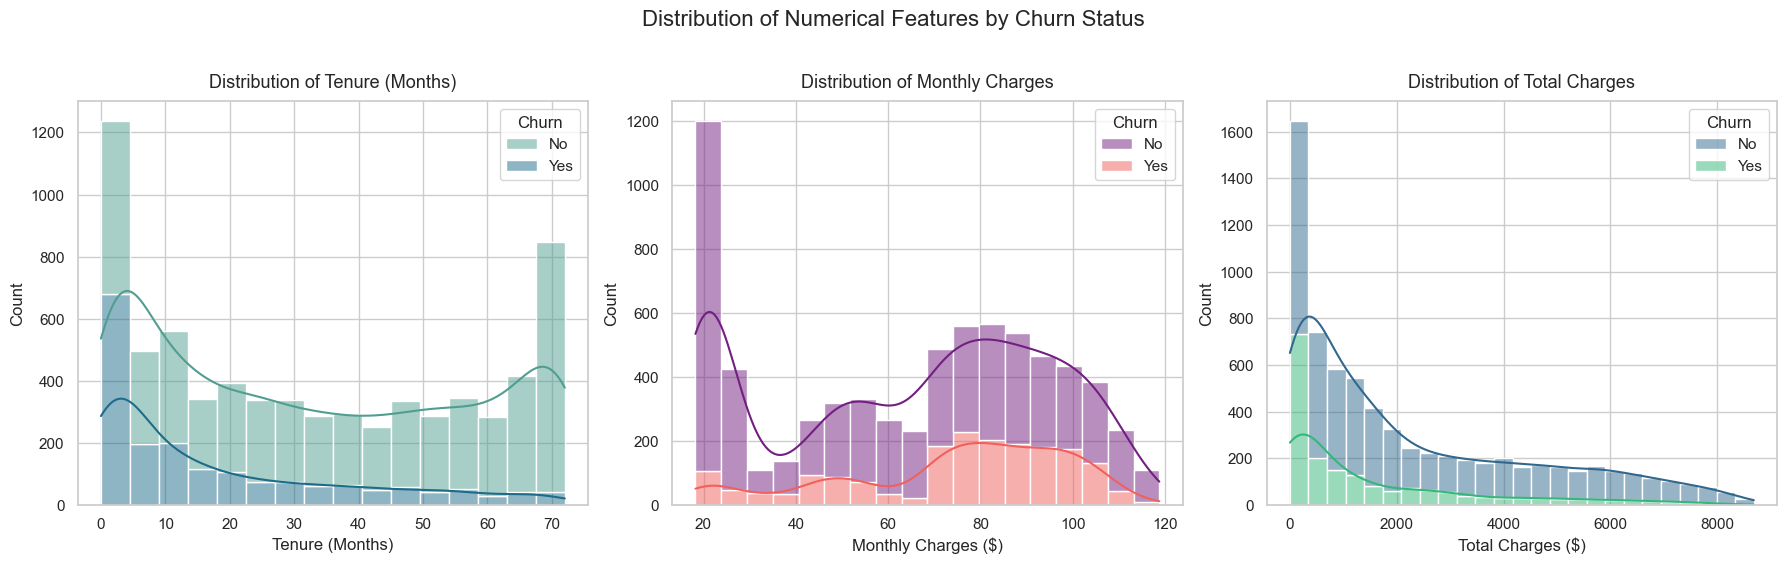

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Tenure distribution
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, multiple='stack', palette='crest', ax=axes[0])
axes[0].set_title('Distribution of Tenure (Months)', fontsize=13, pad=10)
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Count')

# Monthly Charges distribution
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, multiple='stack', palette='magma', ax=axes[1])
axes[1].set_title('Distribution of Monthly Charges', fontsize=13, pad=10)
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Count')

# Total Charges distribution
sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True, multiple='stack', palette='viridis', ax=axes[2])
axes[2].set_title('Distribution of Total Charges', fontsize=13, pad=10)
axes[2].set_xlabel('Total Charges ($)')
axes[2].set_ylabel('Count')

plt.suptitle('Distribution of Numerical Features by Churn Status', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 3. Key Categorical Features Distribution
Let's look at key services and contract options to see which categories show higher churn rates.

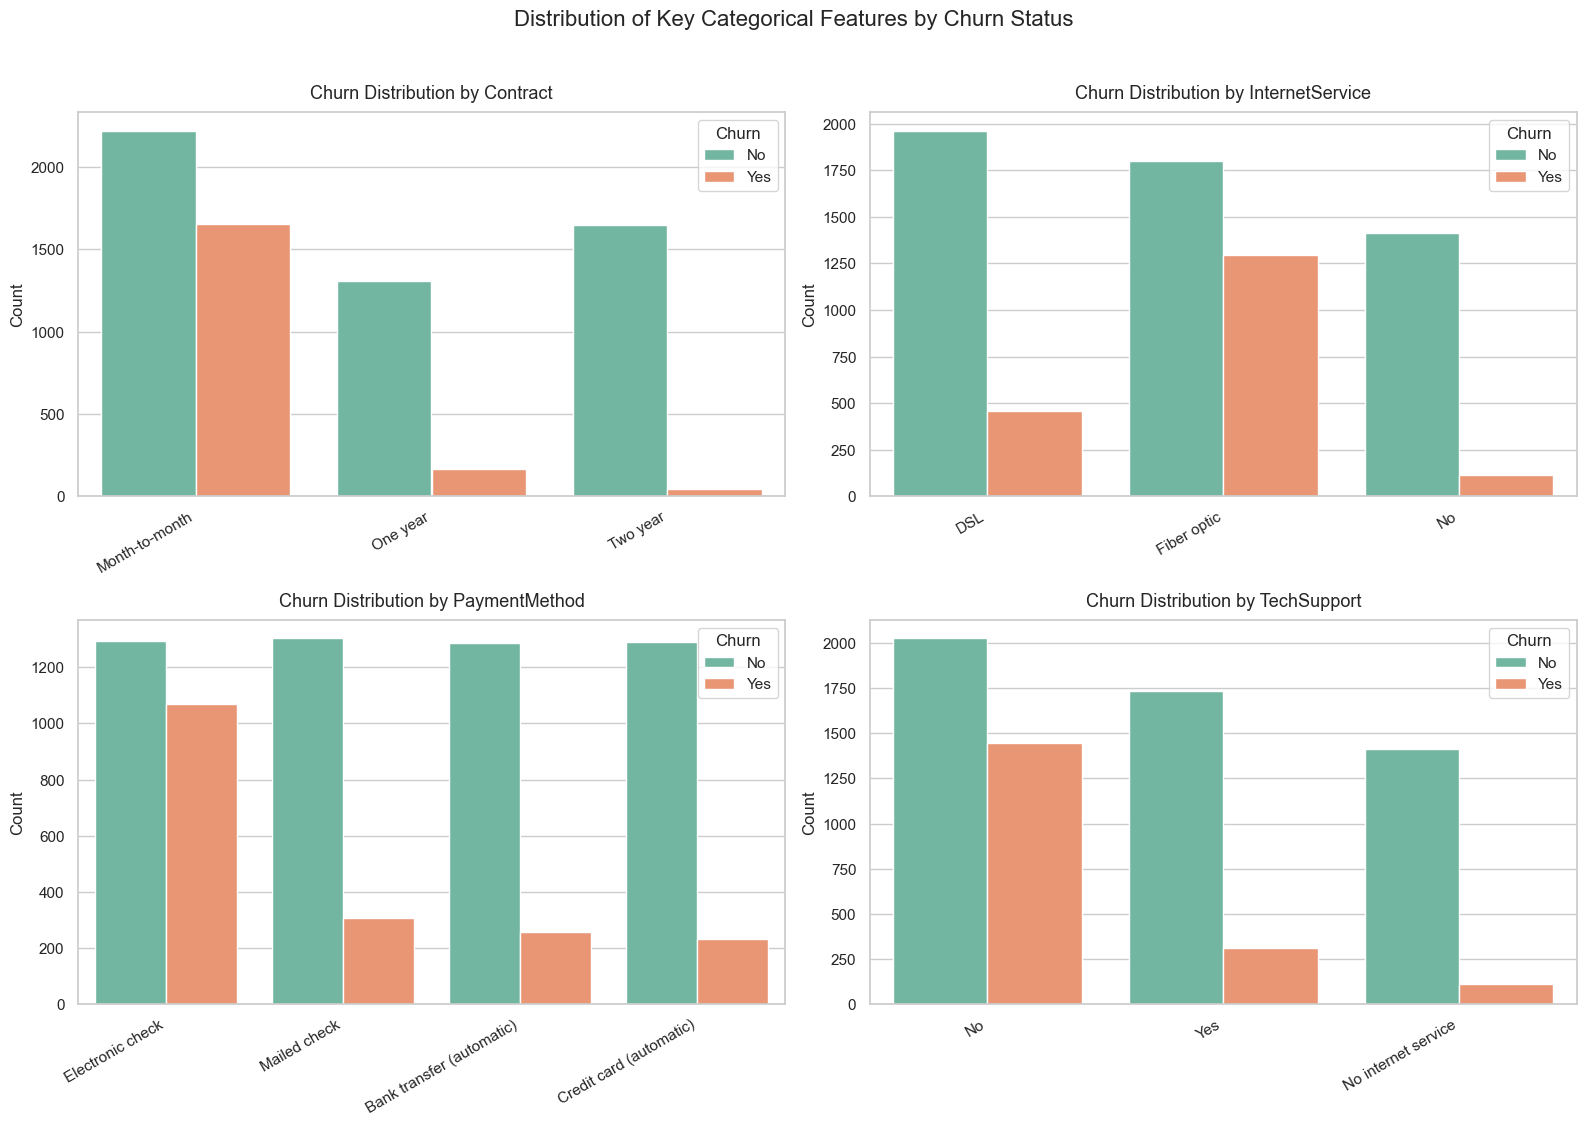

In [11]:
categorical_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='Churn', palette='Set2', ax=axes[i])
    axes[i].set_title(f'Churn Distribution by {col}', fontsize=13, pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    # Rotate the tick labels safely without overwriting their text values
    plt.setp(axes[i].get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Distribution of Key Categorical Features by Churn Status', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Feature Engineering
Instead of using complex loop-based imputations, we impute missing `TotalCharges` for new customers (`tenure=0`) using their `MonthlyCharges` (their first bill). This is logically sound for business contexts.

We also create strong behavioral features rather than redundant numerical ones:
- **NumServices**: The total number of services the customer is using. The more services, the 'stickier' the customer is.
- **AutoPay**: Flag for automatic payment methods.
- **HighRisk**: Classic high-risk profile (Month-to-month contract + Fiber optic + Electronic check).
- **TenureGroup**: Grouping tenure into logical bins.


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import xgboost as xgb, joblib
from sklearn.model_selection import (train_test_split, StratifiedKFold,
        cross_val_score, cross_val_predict, RandomizedSearchCV)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
        roc_auc_score, average_precision_score, confusion_matrix,
        classification_report, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

SEED = 42
sns.set_theme(style='whitegrid')

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Clean missing TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Feature Engineering
svc = ['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
       'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

# The more services, the 'stickier' the customer
df['NumServices'] = (df[svc]=='Yes').sum(axis=1) + (df['InternetService']!='No').astype(int)

# Auto-pay customers typically have lower churn rates
df['AutoPay'] = df['PaymentMethod'].isin(['Bank transfer (automatic)','Credit card (automatic)']).astype(int)

# Classic high-risk segment
df['HighRisk'] = ((df['Contract']=='Month-to-month') &
                  (df['InternetService']=='Fiber optic') &
                  (df['PaymentMethod']=='Electronic check')).astype(int)

# Tenure grouped
df['TenureGroup'] = pd.cut(df['tenure'], bins=[-1,6,12,24,48,72],
                           labels=['0-6','7-12','13-24','25-48','49-72'])


## 5. Encoding & Stratified Splitting
We apply consistent One-Hot Encoding (`drop_first=True`) and perform a stratified train/test split to perfectly preserve the 26.5% churn ratio in both sets.


In [ ]:
y = df['Churn']
X = pd.get_dummies(df.drop(columns=['customerID','Churn']), drop_first=True, dtype=int)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

scale_w = (y_tr==0).sum()/(y_tr==1).sum()
print(f"Train churn={y_tr.mean():.3f} | scale_pos_weight={scale_w:.2f} | "
      f"no-info(test)={1-y_te.mean():.3f}")


## 6. Handling Imbalanced Data: Evidence-based Comparison
Rather than blindly assuming one balancing technique is best, we evaluate three strategies using 5-Fold Cross-Validation, specifically targeting the **F1-Score**.

| Strategy | Description |
|---|---|
| **A. Baseline** | No balancing at all. |
| **B. Scale Weight** | `scale_pos_weight` — Directly adjusts the minority class gradient weights inside the XGBoost loss function. |
| **C. SMOTE** | Generates synthetic minority samples. Placed inside an `imblearn.Pipeline` so it **only applies to the train folds** to prevent data leakage. |

*Note: Since one-hot encoded data is almost entirely binary, SMOTE has to interpolate between 0/1 columns, which can create unnatural synthetic points. Often for boosting trees, native weight adjustment performs equally or better.*


In [ ]:
base = dict(n_estimators=300, learning_rate=0.03, max_depth=3, min_child_weight=5,
            subsample=0.8, colsample_bytree=0.8, gamma=0.3,
            random_state=SEED, eval_metric='logloss')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

strategies = {
    'A_baseline'     : xgb.XGBClassifier(**base),
    'B_scale_weight' : xgb.XGBClassifier(scale_pos_weight=scale_w, **base),
    'C_SMOTE'        : ImbPipeline([('smote', SMOTE(random_state=SEED)),
                                    ('clf', xgb.XGBClassifier(**base))]),
}

results = {}
for name, est in strategies.items():
    f1 = cross_val_score(est, X_tr, y_tr, cv=cv, scoring='f1', n_jobs=-1)
    pr = cross_val_score(est, X_tr, y_tr, cv=cv, scoring='average_precision', n_jobs=-1)
    results[name] = (f1.mean(), f1.std(), pr.mean())
    print(f"{name:15s}  CV-F1 = {f1.mean():.4f} ± {f1.std():.4f}   PR-AUC = {pr.mean():.4f}")

best = max(results, key=lambda k: results[k][0])
print(f"\n>> Winning Strategy (by F1): {best}")


## 7. Hyperparameter Tuning targeted at F1
Using `RandomizedSearchCV`, we search for optimal hyperparameters for the winning strategy, explicitly maximizing the F1-Score.


In [ ]:
grid = {'learning_rate':[0.01,0.02,0.05,0.1], 'max_depth':[3,4,5],
        'min_child_weight':[1,3,5,7], 'gamma':[0,0.1,0.3,0.5],
        'subsample':[0.6,0.8,1.0], 'colsample_bytree':[0.6,0.8,1.0],
        'n_estimators':[200,300,400]}

if best == 'C_SMOTE':
    est = ImbPipeline([('smote', SMOTE(random_state=SEED)),
                       ('clf', xgb.XGBClassifier(random_state=SEED, eval_metric='logloss'))])
    grid = {f'clf__{k}': v for k, v in grid.items()}
elif best == 'B_scale_weight':
    est = xgb.XGBClassifier(scale_pos_weight=scale_w, random_state=SEED, eval_metric='logloss')
else:
    est = xgb.XGBClassifier(random_state=SEED, eval_metric='logloss')

search = RandomizedSearchCV(est, grid, n_iter=30, scoring='f1', cv=cv,
                            n_jobs=-1, random_state=SEED, verbose=1)
search.fit(X_tr, y_tr)
best_est = search.best_estimator_
print(f"\nBest CV-F1: {search.best_score_:.4f}")
print("Optimal Parameters:", search.best_params_)


## 8. Optimal Threshold Selection on Out-Of-Fold
The default threshold of 0.5 is almost never optimal for maximizing F1 on highly imbalanced data. Instead of peeking at the test set, we obtain **Out-of-Fold (OOF)** predicted probabilities from the training set to pick the best threshold. This guarantees our test evaluation remains unbiased.


In [ ]:
oof = cross_val_predict(best_est, X_tr, y_tr, cv=cv,
                        method='predict_proba', n_jobs=-1)[:, 1]
prec, rec, thr = precision_recall_curve(y_tr, oof)
f1_curve = 2*prec*rec / (prec + rec + 1e-9)
best_t = float(thr[np.argmax(f1_curve[:-1])])
print(f"Optimal F1 Threshold (OOF) = {best_t:.3f}  |  OOF-F1 = {f1_curve[:-1].max():.4f}")


## 9. Final Evaluation on the Test Set
We compare the performance of the default threshold (0.5) against our mathematically optimized threshold to measure the direct business impact of shifting the boundary.


In [ ]:
best_est.fit(X_tr, y_tr)
p_te = best_est.predict_proba(X_te)[:, 1]

def report(tag, t):
    pred = (p_te >= t).astype(int)
    print(f"--- {tag} (threshold={t:.3f}) ---")
    print(f"  Accuracy={accuracy_score(y_te,pred):.4f}  Precision={precision_score(y_te,pred):.4f}"
          f"  Recall={recall_score(y_te,pred):.4f}  F1={f1_score(y_te,pred):.4f}")
    return pred

print(f"ROC-AUC = {roc_auc_score(y_te,p_te):.4f}   PR-AUC = {average_precision_score(y_te,p_te):.4f}\n")
report("Default Threshold", 0.5)
pred = report("Optimized F1 Threshold", best_t)
print("\n", classification_report(y_te, pred, target_names=['Stayed','Churned']))

fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
cm = confusion_matrix(y_te, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stayed','Churned'], yticklabels=['Stayed','Churned'], ax=ax[0])
ax[0].set_title(f'Confusion Matrix @ threshold={best_t:.2f}')
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Actual')
ax[1].plot(rec, prec); ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
ax[1].set_title(f'Precision-Recall curve (PR-AUC={average_precision_score(y_te,p_te):.3f})')
plt.tight_layout(); plt.show()


## 10. Model Explainability with SHAP
A churn model is only as useful as the retention strategies it informs. SHAP provides insight into exactly *why* individual customers are flagged for churn, enabling targeted actions.
*(Run `pip install shap` if not yet installed)*


In [ ]:
try:
    import shap
    model = best_est.named_steps['clf'] if hasattr(best_est, 'named_steps') else best_est
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_te)
    shap.summary_plot(sv, X_te, plot_type='bar', max_display=12, show=True)
except ImportError:
    print("SHAP is not installed. Run: pip install shap")


## 11. Saving Artifacts for Deployment
To properly deploy the model into production (e.g. into Camunda workflows), we must save both the trained model `.pkl` file **AND** the vital metadata (the optimized threshold and feature schema).


In [ ]:
joblib.dump(best_est, 'churn_model.pkl')
joblib.dump({'threshold': best_t, 'features': list(X_tr.columns),
            'strategy': best}, 'churn_metadata.pkl')
print("Successfully Saved: churn_model.pkl and churn_metadata.pkl")
